- đọc lại JSON
- df_new = pd.read_json('law.json', orient='records')


In [6]:
!pip install pytorch_lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 30.3 MB/s eta 0:00:00


# Import library

In [9]:
# @
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
import re

import json

from collections import defaultdict


#BERT
# @
from transformers import BertTokenizer, BertForSequenceClassification
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import train_test_split

import pytorch_lightning as pl

from transformers import BertTokenizerFast as BertTokenizer, BertModel, get_linear_schedule_with_warmup
from torch.optim import AdamW


upload file json ở tab menu bên phải của gg colab

In [10]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Tên file

In [4]:
# tên file
folder = "final"
version = "_final"
LAW_FILE = f"/content/drive/MyDrive/{folder}/law{version}.json"
CASE_FILE =f"/content/drive/MyDrive/{folder}/case{version}.json"
CASE_LAW_FILE = f"/content/drive/MyDrive/{folder}/case_law{version}.json"
GROUND_TRUTH_FILE = f"/content/drive/MyDrive/{folder}/ground_truth{version}.json"  #chỉ điều

DF_DATASET_DICT_FILE = f"/content/drive/MyDrive/{folder}/df_dataset_dict{version}.json"

TRAIN_FILE = f"/content/drive/MyDrive/{folder}/train{version}.json"
VAL_FILE = f"/content/drive/MyDrive/{folder}/val{version}.json"
TEST_FILE = f"/content/drive/MyDrive/{folder}/test{version}.json"

print(LAW_FILE)
print(CASE_FILE)
print(CASE_LAW_FILE)
print(GROUND_TRUTH_FILE)

/content/drive/MyDrive/final/law_final.json
/content/drive/MyDrive/final/case_final.json
/content/drive/MyDrive/final/case_law_final.json
/content/drive/MyDrive/final/ground_truth_final.json


In [ ]:
# check file vừa upload
!ls /content


drive  sample_data


In [11]:
df_law = pd.read_json(LAW_FILE, orient='records')
df_law.head()

,id,article,title,content,type
0,1,Điều 1,Nhiệm vụ của Bộ luật hình sự,"""{\""info\"": \""Bộ luật hình sự có nhiệm vụ bảo ...",hình sự
1,2,Điều 2,Cơ sở của trách nhiệm hình sự,"""{\""info\"": \""\"", \""1\"": \""Chỉ người nào phạm ...",hình sự
2,3,Điều 3,Nguyên tắc xử lý,"""{\""info\"": \""\"", \""1\"": {\""a\"": \""Mọi hành vi...",hình sự
3,4,Điều 4,Trách nhiệm phòng ngừa và đấu tranh chống tội ...,"""{\""info\"": \""\"", \""1\"": \""Cơ quan Công an, Vi...",hình sự
4,5,Điều 5,Hiệu lực của Bộ luật hình sự đối với những hàn...,"""{\""info\"": \""\"", \""1\"": \""Bộ luật hình sự đượ...",hình sự


In [ ]:
df_case_law = pd.read_json(CASE_LAW_FILE, orient='records')
df_case_law.head()

,case_id,point,clause,article,type,note
0,1,i,1,51,hình sự,None
1,1,s,1,51,hình sự,None
2,1,None,2,51,hình sự,None
3,1,g,1,52,hình sự,None
4,1,None,None,35,hình sự,None


In [ ]:
df_case = pd.read_json(CASE_FILE, orient='records')
df_case.head()

,id,content,text
0,1,Vũ Tuấn T về tội “Cho vay lãi nặng trong giao ...,...
1,2,Tuyên bố bị cáo Trần Anh D phạm tội “Vi phạm ...,1 \n \nTÒA ÁN NHÂN DÂN \nCỘNG HÒA XÃ HỘI CHỦ N...
2,3,Cao Văn L,\n1 \nTÒA ÁN NHÂN DÂN QUẬN \nLONG BIÊN – TP H...
3,4,"Khoảng 12 giờ 30 phút ngày 26/01/2018, Phan Th...",TÒA ÁN NHÂN DÂN \nCỘNG HÒA XÃ HỘI CHỦ N...
4,5,Vi Van T phạm tội vi phạm quy định về quản lý...,2 \nTÒA ÁN NHÂN DÂN \nHUYỆN QUAN SƠN \nTỈNH TH...


In [13]:
#HÀM TIỀN XỬ LÝ
def preprocess_text(text):
    # text k la str => rỗng
    if not isinstance(text, str):
        return ""
    # chữ thường
    text = text.lower()

    # chuyển từ viết tắt
    abbrList = {
        'blhs': 'bộ luật hình sự',
        'tths': 'tố tụng hình sự',
        'thhs': 'thi hành hình sự',
        'blds': 'bộ luật dân sự',
        'ttds': 'tố tụng dân sự',
        'thds': 'thi hành dân sự'
    }

    for abbr, full_form in abbrList.items():
        text = text.replace(abbr, full_form)


    text = unicodedata.normalize("NFC", text) # chuẩn hóa mã hóa Unicode > đồng nhất
    text = re.sub(r"[^a-zA-ZÀ-Ỹà-ỹ0-9\s]", " ", text) #giữ chữ, số , loại kí tự đbiet

    # khoảng trắng thừa = 1 space
    while '  ' in text:
        text = text.replace('  ', ' ')

    text = text.strip() # xoa space đầu cuối


    return text


In [ ]:
# test
text = "Blhs và tths quy định thế nào? Thhs, blds, ttds, thds liên quan. blhs.                          abc"
result = preprocess_text(text)
print(result)

bộ luật hình sự và tố tụng hình sự quy định thế nào thi hành hình sự bộ luật dân sự tố tụng dân sự thi hành dân sự liên quan bộ luật hình sự abc


In [14]:
# HÀM XỬ LÝ TEXT CỦA BẢNG CASE
# chữ thường
# chuyển từ viết tắt
# loại kí tự đặc biệt
# xóa khoảng trắng thừa

def preprocess_case(text):
    # text không phải string thì trả về rỗng
    if not isinstance(text, str):
        return ""

    # chữ thường
    text = text.lower()
    # chuyển từ viết tắt
    abbrList = {
        'blhs': 'bộ luật hình sự',
        'tths': 'tố tụng hình sự',
        'thhs': 'thi hành hình sự',
        'blds': 'bộ luật dân sự',
        'ttds': 'tố tụng dân sự',
        'thds': 'thi hành dân sự'
    }
    for abbr, full_form in abbrList.items():
        text = text.replace(abbr, full_form)

    # chuẩn hóa Unicode
    text = unicodedata.normalize("NFC", text)

    # chỉ giữ chữ, số, khoảng trắng, dấu chấm, dấu phẩy
    text = re.sub(r"[^a-zA-ZÀ-Ỹà-ỹ0-9\t\.,]", " ", text)

    delete_text = [
        "thành phố",
        "quận",
        "bà",
        "ông",
        "cộng hòa xã hội chủ nghĩa việt nam",
        "cộng hoà xã hội chủ nghĩa việt nam",
        "độc lập tự do hạnh phúc",
        "bản án số",
        "tòa", "toà",
        "án nhân dân",
        "thành phần hội đồng xét xử",
        "gồm có",
        "nhân danh",
        "thẩm phán",
        "chủ toạ phiên", "chủ tọa phiên",
        "các hội thẩm nhân dân",
        "thư ký",
        "phiên",
        "viện kiểm sát nhân dân",
        "kiểm sát nhân dân",
        "kiểm sát viên",
        "hội đồng xét xử",
        "ngày", "tháng", "năm",
        "thụ lý số",
        "nghị quyết",
        "quyết định",
        "thông tư",
        "pháp lệnh",
    ]

    for item in delete_text:
        text = text.replace(item, "")

    # Bước 4: Xóa khoảng trắng thừa

    # khoảng trắng thừa = 1 space
    while '  ' in text:
        text = text.replace('  ', ' ')

    text = text.strip() # xoa space đầu cuối

    return text




In [ ]:
# tiền xử lý cột TEXT của bảng CASE
df_case["text"] = df_case["text"].apply(preprocess_case)

In [ ]:
#test
text = "hôm nay trời mưa \n hôm qua trời nắng . mai . . . hu hu , hu"
text = preprocess_case(text)
print(text)

hôm nay trời mưa hôm qua trời nắng . mai . . . hu hu , hu


## Xử lý bảng law

In [15]:
#XỬ LÝ BẢNG LAW
# tạo mảng lưu vết id
law_article_ids = []
law_detail_ids = [] # detail = điểm, khoản, điều
#mảng lưu văn bản
law_article_list = []
law_detail_list = []


count_lawID = 0
for index, row in df_law.iterrows():
    count_lawID +=1
    article = row['article']
    title = row['title'] or ""
    law_type = row['type']
    law_id = row['id']
    content =""
    #chuyen json thanh dlieu python
    content_json = row["content"]
    # print(">>> TYPE content_json:", type(content_json))
    try:
        if isinstance(content_json, str):
            content = json.loads(content_json)
            # print(">>> TYPE content:", type(content))
            if isinstance(content, str):
                # load json 1
                content = json.loads(content)
                # print(">>> TYPE content:", type(content))


    except Exception as e:
        print(e)

    # # điều > khoản key, value
    all_clause_value = ""
    for clause_key, clause_value in content.items():
        # print("clause_key",clause_key)
        # print("clause_value",clause_value)

        # nếu khoản là string > mỗi khoản
        if isinstance(clause_value, str):
            if clause_key == "info":
                if not clause_value or clause_value.strip() == "":
                        continue  # bỏ qua nếu info rỗng
                else: # content cua luat

                    clean_clause_value = preprocess_text(clause_value)
                    full_text = f"{clean_clause_value}"

                    # them vao mang document
                    # law_documents.append(full_text) vi end for nay thi van add law_id thoi
                    # law_doc_ids.append(f"{law_id}") vi end for nay thi van add law_id thoi

                    all_clause_value += "- " +full_text + "\n"
            else:
                #khoan 1 dieu 2 bo luat hinh su
                heading = f"khoản {clause_key} {article} {law_type}"

                # lam sach du lieu
                clean_heading = preprocess_text(heading)
                clean_clause_value = preprocess_text(clause_value)
                full_text = f"{clean_heading}: {clean_clause_value}"

                # them vao mang document
                law_detail_list.append(full_text)
                law_detail_ids.append(f"{law_id}_{clause_key}")

                # print("law id", law_id)
                # print("clean_text",clean_text)

                all_clause_value += "- " + full_text + "\n"

        # khoản là dict >> có điểm
        elif isinstance(clause_value, dict):
            all_point_value = ""
            for point_key, point_value in clause_value.items():
                # print("point_key",point_key)
                # print("point_value",point_value)

                heading = f"điểm {point_key} khoản {clause_key} {article} {law_type}"
                clean_heading = preprocess_text(heading)
                clean_point_value = preprocess_text(point_value)
                full_text = f"{clean_heading}: {clean_point_value}"

                law_detail_list.append(full_text)
                law_detail_ids.append(f"{law_id}_{clause_key}_{point_key}")

                # print("law id", law_id)
                # print("clean_text",clean_text)

                all_point_value +="-- " + full_text + "\n"


            # end for, end duyệt point của clause val htai => add all point
            # print(all_point_value)
                # điểm a khoản 2 điều 3 hình sự: mọi hành vi ph
                # điểm b khoản 2 điều 3 hình sự: mọi pháp nhân thươ
                # điểm c khoản 2 điều 3 hình sự: nghiêm trị pháp nhân th
                # điểm d khoản 2 điều 3 hình sự: khoan hồng đối với pháp
            # thêm vào law documents , thêm law_id: khoản 2 điều 3


            heading = f"khoản {clause_key} {article} {law_type}"
            clean_heading = preprocess_text(heading)
            full_text_all_point = f"{clean_heading}:\n{all_point_value}"


            all_clause_value += "+ " +full_text_all_point + "\n"

            law_detail_list.append(all_clause_value)
            law_detail_ids.append(f"{law_id}_{clause_key}")


    # end for clause
    # add law documents, thêm law_id : điều 3
    # print(all_clause_value)
    heading = f"{article} {law_type}"
    clean_heading = preprocess_text(heading)
    full_text_all_clause = f"{clean_heading}:\n{all_clause_value}"

    law_article_list.append(full_text_all_clause)
    law_article_ids.append(f"{law_id}")

    law_detail_list.append(full_text_all_clause)
    law_detail_ids.append(f"{law_id}")

    # #test
    # if article == "Điều 1":print(full_text_all_clause)




In [ ]:
def get_law_id_from_json(df, article, law_type):
    result = df[(df['article'] == article) & (df['type'] == law_type)]
    if not result.empty:
        return result['id'].iloc[0]
    return None

In [ ]:
#test
law_id = get_law_id_from_json(df_law, "Điều 1", "tố tụng hình sự")
print(law_id)

427


## ground_truth_article_dict

In [ ]:
def normalize_text(s):
    if s is None:
        return ""
    return " ".join(str(s).strip().lower().split())  # bỏ space thừa đầu/cuối và chuẩn hóa khoảng trắng

#GROUND TRUTH
# dict ground_truth
ground_truth_article_dict = defaultdict(list)
ground_truth_detail_dict = defaultdict(list)
#get law_id
for index, row in df_case_law.iterrows():
    case_id = row['case_id']
    article = row['article']
    clause = row['clause']
    point = row['point']


    case_law_type = row['type']
    # TYPE ĐANG DƯ SPACE 9000,,2,136,"tố tụng hình sự ",
    case_law_type = normalize_text(case_law_type)
    note = row['note']

    article_text = f"Điều {article}"

    # print(case_id, " ",article, " ",clause, " ", point, " ", note )

    #get law_id
    # param tham so truyen vao phai la 1 tuple () or dict
    # param = (article_text, case_law_type)
    # law_id = get_law_id_from_db(engine, param )

    law_id = get_law_id_from_json(df_law,article_text,case_law_type)

    # mỗi lần lặp thì reset key
    article_key = clause_key = point_key = ""
    # law_id none là các điều nằm ngoài h.sự
    if law_id == None:
        continue
    else:
        article_key = f"{law_id}"
        if clause == None:
            clause_key = ""
        else:
            clause_key = f"_{clause}"
            if point == None:
                point_key = ""
            else: point_key = f"_{point}"




    # law_id_clause_point (article => law_id)

    full_law_id = article_key + clause_key + point_key
    if full_law_id =="": continue # bỏ qua những luật ngoài hình sự
    # print(case_id, "_",target_id)

    # 1 _ 51_1_i
    # 1 _ 51_1_s
    # 1 _ 51_2
    # 1 _ 52_1_g
    # 1 _ 35
    # 1 _ 47_1_a

    law_of_caseid_arr = ground_truth_article_dict[case_id]
    if article_key not in law_of_caseid_arr:
        ground_truth_article_dict[case_id].append(article_key)
    ground_truth_detail_dict[case_id].append(full_law_id)




#test

print("chỉ điều: ", ground_truth_article_dict)
print("len: ",len( ground_truth_article_dict))

print("all: ", ground_truth_detail_dict)
print("len: ",len( ground_truth_detail_dict))



chỉ điều:  defaultdict(<class 'list'>, {1: ['51', '52', '35', '47', '532', '201'], 2: ['244', '51', '532', '1005', '65', '47', '562', '757', '759'], 3: ['244', '51', '65', '47', '532', '1005', '562', '757', '759'], 4: ['244', '51', '38', '781', '783', '1005', '65'], 5: ['244', '51', '65', '35', '562', '757', '759', '1005'], 6: ['244', '51', '65', '532', '1005', '754', '562', '757', '759'], 7: ['244', '51', '65', '532', '190', '1005', '562'], 8: ['244', '51', '58', '65', '532', '47', '757', '562', '759', '35', '52', '1005'], 9: ['244', '51', '65', '190', '562', '1005', '234'], 10: ['244', '65', '51', '532', '1005'], 11: ['244', '51', '54'], 12: ['244', '51', '532', '47', '562', '52'], 13: ['244', '51', '65', '47', '532', '1005', '562'], 14: ['51', '244', '65', '1005', '46', '47', '561', '532', '562', '757', '759'], 15: ['244', '51', '1005', '562', '65', '47', '532'], 17: ['244', '51', '562', '38', '54', '532'], 18: ['51', '244', '532', '65', '1005', '561', '562'], 19: ['244', '51', '52'

## save + load file json

In [ ]:
# @
def save_file_json(name_file, text_list):
  # --- Lưu vào file JSON ---
  with open(name_file, "w", encoding="utf-8") as f:
      json.dump(text_list, f, ensure_ascii=False, indent=2)

def load_file_json(name_file):
  # --- Đọc lại từ file JSON ---
  with open(name_file , "r", encoding="utf-8") as f:
      loaded_list = json.load(f)
  return loaded_list

In [ ]:
# GROUND_TRUTH_FILE = "ground_truth_article_dict9000.json"
save_file_json( GROUND_TRUTH_FILE,ground_truth_article_dict)
ground_truth = load_file_json(GROUND_TRUTH_FILE)
print(ground_truth)

ground_truth_article_dict = ground_truth

{'1': ['51', '52', '35', '47', '532', '201'], '2': ['244', '51', '532', '1005', '65', '47', '562', '757', '759'], '3': ['244', '51', '65', '47', '532', '1005', '562', '757', '759'], '4': ['244', '51', '38', '781', '783', '1005', '65'], '5': ['244', '51', '65', '35', '562', '757', '759', '1005'], '6': ['244', '51', '65', '532', '1005', '754', '562', '757', '759'], '7': ['244', '51', '65', '532', '190', '1005', '562'], '8': ['244', '51', '58', '65', '532', '47', '757', '562', '759', '35', '52', '1005'], '9': ['244', '51', '65', '190', '562', '1005', '234'], '10': ['244', '65', '51', '532', '1005'], '11': ['244', '51', '54'], '12': ['244', '51', '532', '47', '562', '52'], '13': ['244', '51', '65', '47', '532', '1005', '562'], '14': ['51', '244', '65', '1005', '46', '47', '561', '532', '562', '757', '759'], '15': ['244', '51', '1005', '562', '65', '47', '532'], '17': ['244', '51', '562', '38', '54', '532'], '18': ['51', '244', '532', '65', '1005', '561', '562'], '19': ['244', '51', '52', '

# BERT

## Tham số

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

LEARNING_RATE = 2e-5 # tốc độ học
DROPOUT = 0.5 # 50% để tránh overfit

# N_EPOCHS = 2 #Số vòng lặp qua toàn bộ dataset khi train
# BATCH_SIZE = 4
# gpu
N_EPOCHS = 2
BATCH_SIZE = 16

len_law_article_ids = len(law_article_ids)
# print(len_law_article_ids) # 1122


In [ ]:
# text_input # là bản án (text của case)
# label # nhãn đầu ra = list law

# tokenize

# tạo ma trận nhị phân cho ground truth
# law_list_ids = [1, 2, 3, 4, 5]
# ground_truth = {
#     1: [3, 5],
#     2: [1, 4],
#     3: [2, 5]
# }

# [   [0 0 1 0 1]
#     [1 0 0 1 0]
#     [0 1 0 0 1] ]

#law id nằm ở index nào = id_to_index

# có ground truth dict

# # lay arr chứa value của dict
# labels = list(ground_truth.values() )

#test
# print(labels)
# for item in labels:
#     print(item)

## convert_labels_to_binary_vector

In [ ]:
#arr_laws là labels
# @
def convert_labels_to_binary_vector(arr_laws, len_all_law_ids, id_to_index):
    res = [0] * len_all_law_ids
    for law in arr_laws:
        if law in id_to_index:
            res[id_to_index[law]] = 1 # law trong list_all_law này có trong groundtruth của case id này

    return res


## id_to_index

In [ ]:
# @
id_to_index = {}
for index , law_id in enumerate(law_article_ids):
        id_to_index[law_id] = index

# print(id_to_index)




In [ ]:
caseID_list =[]
text_list =[]
for index, row in df_case.iterrows():
    case_id = row['id']
    text = row['text']
    text = preprocess_case(text)
    caseID_list.append(case_id)
    text_list.append(text)

print(caseID_list)
print(len(caseID_list))
print(text_list)



Buffered data was truncated after reaching the output size limit.

In [ ]:
# # save_file_json("case_list.json",text_list)
# save_file_json("caseID_list.json", caseID_list)

# caseID_list = load_file_json("caseID_list.json")
# text_list1 = load_file_json("case_list.json")


# print(text_list1)
# print(caseID_list)

In [ ]:
# ground truth {case_id: list law_id} : ground_truth
# chuyển ground truth dict -> data frame
df_ground_truth = pd.DataFrame(list(ground_truth.items()), columns=["id", "laws"])
df_ground_truth['id'] = df_ground_truth['id'].astype(int)
# ----- B2: Join với bảng case để lấy text -----
# df_dataset có dạng:
# case_id | text | [list law_id]

df_dataset = pd.merge(
    df_case[['id', 'text']],   # Chỉ lấy 2 cột cần
    df_ground_truth,
    on='id',
    how='inner'
)

print(df_dataset)
df_dataset_dict = df_dataset.to_dict(orient="records")

# @@@
save_file_json(DF_DATASET_DICT_FILE, df_dataset_dict)

        id                                               text  \
0        1  ngô quyền hải phòng 98 2021 hs st 18 6 2021 độ...   
1        2  1 tây hồ độc lập tự do hạnh phúc hà nội 113 20...   
2        3  1 long biên tp hà nội 165 2018 hs st 13 06 201...   
3        4  hồ chí minh độc lập tự do hạnh phúc 355 2018 h...   
4        5  2 huyện quan sơn tỉnh thanh hóa 04 2018 hs st ...   
...    ...                                                ...   
8029  8996  thị xã thuận an tỉnh bình dƣơng 104 2019 hs st...   
8030  8997  thị xã thuận an tỉnh bình dƣơng 255 2019 hs st...   
8031  8998  thị xã thuận an tỉnh bình dƣơng 244 2019 hs st...   
8032  8999  thị xã thuận an tỉnh bình dƣơng 129 2019 hs st...   
8033  9000  huyện bắc quang tỉnh hà giang 46 2019 hs st 08...   

                                                   laws  
0                            [51, 52, 35, 47, 532, 201]  
1           [244, 51, 532, 1005, 65, 47, 562, 757, 759]  
2           [244, 51, 65, 47, 532, 1005, 562,

In [ ]:
# @
dataset_dict = load_file_json(DF_DATASET_DICT_FILE)
df_dataset_from_dict = pd.DataFrame(dataset_dict)
print(df_dataset_from_dict)


        id                                               text  \
0        1  ngô quyền hải phòng 98 2021 hs st 18 6 2021 độ...   
1        2  1 tây hồ độc lập tự do hạnh phúc hà nội 113 20...   
2        3  1 long biên tp hà nội 165 2018 hs st 13 06 201...   
3        4  hồ chí minh độc lập tự do hạnh phúc 355 2018 h...   
4        5  2 huyện quan sơn tỉnh thanh hóa 04 2018 hs st ...   
...    ...                                                ...   
8029  8996  thị xã thuận an tỉnh bình dƣơng 104 2019 hs st...   
8030  8997  thị xã thuận an tỉnh bình dƣơng 255 2019 hs st...   
8031  8998  thị xã thuận an tỉnh bình dƣơng 244 2019 hs st...   
8032  8999  thị xã thuận an tỉnh bình dƣơng 129 2019 hs st...   
8033  9000  huyện bắc quang tỉnh hà giang 46 2019 hs st 08...   

                                                   laws  
0                            [51, 52, 35, 47, 532, 201]  
1           [244, 51, 532, 1005, 65, 47, 562, 757, 759]  
2           [244, 51, 65, 47, 532, 1005, 562,

In [ ]:

# df_dataset = df_dataset_from_dict

# ----- B3: Chia train/test theo case_id -----

# 70% train
# 15% validation
# 15% test

train_df, temp_df = train_test_split(df_dataset, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)





In [ ]:
#test
train_df.head()

,id,text,laws
5741,5991,1 tây ninh tỉnh tây ninh 33 2018 hs st 21 6 20...,"[562, 249, 46, 47, 51, 532]"
1272,1338,1 g độc lập tự do hạnh phúc tỉnh kiên giang 17...,"[249, 51, 38, 46, 47, 52, 532, 525]"
1411,1481,1 long biên hà nội 265 2018 hs st 23 10 2018 đ...,"[249, 38, 51, 532, 47, 562, 759, 757]"
7086,8010,"1 huyện phù yên, tỉnh sơn la 80 2019 hs st 29 ...","[561, 47, 515, 532, 249, 473, 51, 562]"
7344,8285,1 huyện mèo vạc độc lập tự do hạnh phúc tỉnh h...,"[757, 47, 532, 51, 249, 759, 38]"


In [ ]:
val_df.head()

,id,text,laws
4522,4709,"1 huyện phù yên, độc lập tự do hạnh phúc tỉnh ...","[759, 758, 532, 47, 249, 51]"
1563,1637,1 t phố b tỉnh b 194 2018 hs st 29 11 2018 độc...,"[52, 51, 249, 58, 17, 38, 532, 47, 562, 757, 7..."
6309,6774,1 huyện bình giang tỉnh hải dương 11 2018 hs s...,"[47, 249, 38, 46, 7, 51, 194, 561, 562, 532]"
7432,8375,1 huyện n tỉnh điện biên 60 2019 hs st 18 11 2...,"[58, 51, 47, 52, 249, 759, 562, 757, 17, 532, 38]"
4739,4939,1 huyện đắk mil tỉnh đắk n 31 2018 hsst 27 8 2...,"[562, 718, 48, 47, 532, 38, 54, 51, 249]"


In [ ]:
test_df.head()

,id,text,laws
4348,4530,1 cộng hòa xã hội chủ nghĩa việt nam thanh hóa...,"[449, 562, 532, 56, 38, 58, 51, 249]"
4148,4324,1 tßa n nh n d n sơn la tønh s n la b n n sè 1...,"[755, 562, 532, 249, 51]"
2091,2171,n tỉnh nam định 325 2018 hsst 29 11 2018 độc l...,"[249, 51, 52, 562, 47]"
2718,2814,huyện yên châu tỉnh sơn la 64 2018 hs st 30 10...,"[249, 47, 51, 532, 562]"
7494,8437,1 tand nam từ liêm hà nội c hòa xã hội chủ ngh...,"[249, 38, 755, 51, 562, 47, 532, 52]"


## lưu file train val test

In [ ]:
# ----- B4: Xuất ra file -----

train_df.to_json(TRAIN_FILE, orient="records", force_ascii=False)
val_df.to_json(VAL_FILE, orient="records", force_ascii=False)
test_df.to_json(TEST_FILE, orient="records", force_ascii=False)

In [ ]:
print("Số mẫu train:", len(train_df))
print("Số mẫu val:", len(val_df))
print("Số mẫu test:", len(test_df))

Số mẫu train: 5623
Số mẫu val: 1205
Số mẫu test: 1206


In [ ]:
print("train, ", "val" , 'test')
train_df.shape, val_df.shape , test_df.shape

train,  val test


((5623, 3), (1205, 3), (1206, 3))

# Tokenization
Chúng ta cần chuyển đổi raw text thành 1 list tokens bằng
BertTokenizer

In [ ]:
BERT_MODEL_NAME = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

thử trên 1 bản án

In [ ]:
# # @
# # lấy thử 1 case id
# sample_row = df_dataset.iloc[0] # lấy dòng thứ 1
# # print(sample_row)

# sample_case = sample_row.text
# arr_laws = sample_row.laws
# print(sample_case)

# sample_labels = convert_labels_to_binary_vector(arr_laws, len_law_article_ids, id_to_index)

# print(" ".join(map(str, sample_labels)))



- tokenization process trong PyTorch Dataset
- chuyển labels thành tensors

# BERT DATASET

In [ ]:
# df_dataset có dạng:
# case_id | text | [list law_id]

# Dataset cho bản án
class BERT_Dataset(Dataset):
    def __init__(self,
                 df_dataset,
                 tokenizer, #tokenizer để encode văn bản (BertTokenizer)
                 len_all_laws ,
                 id_to_index,
                 max_token_len=512 #số token tối đa cho mỗi đoạn
                 ):

        self.samples = []  # sẽ chứa nhiều (chunk, label)
        self.tokenizer = tokenizer
        self.max_token_len = max_token_len


        # Duyệt từng văn bản và nhãn tương ứng
        for _, row in df_dataset.iterrows():
          case_id = row['id']
          text = row['text']
          arr_laws = row['laws']
          # Tạo vector nhị phân cho case này
          label_vector = convert_labels_to_binary_vector(arr_laws, len_all_laws, id_to_index)
          # Encode de Tokenize văn bản thành list số (token IDs)  # encode text thành token IDs (ko thêm special token trước)
          token_ids = tokenizer.encode(text,add_special_tokens=False ) # true de thêm [CLS], [SEP]
          # Cắt thành nhiều đoạn 512
          for start_index in range(0, len(token_ids), max_token_len-2): # 2 cho cho cls , sep
            end_index = start_index + (max_token_len-2)
            chunk = token_ids[start_index:end_index]
            # Thêm [CLS], [SEP] thủ công
            chunk_tokens = [tokenizer.cls_token_id] + chunk + [tokenizer.sep_token_id]

            # pad cho đủ max_len
            padding_len = max_token_len - len(chunk_tokens)
            input_ids = chunk_tokens + [tokenizer.pad_token_id] * padding_len

            # mask: 1 cho token thật, 0 cho pad
            attention_mask = [1] * len(chunk_tokens) + [0] * padding_len
            # lưu tuple (input_ids, mask, labels)
            self.samples.append((case_id, input_ids, attention_mask, label_vector))


    # số lượng mẫu trong dataset , Trả về số lượng mẫu (tổng số chunk)
    def __len__(self):
        return len(self.samples)

    """
        Lấy 1 mẫu tại chỉ số idx
        Trả về dict với 3 key: input_ids, attention_mask =real token mask, labels
    """
    def __getitem__(self, index):
        case_id, input_ids, attention_mask, label_vector = self.samples[index]

        #TEST
        assert len(input_ids) == 512, f"Input length {len(input_ids)} > 512"
        # tokens, label = self.samples[index]

        # # Tính số lượng padding cần thêm (số token còn thiếu để đủ 512)
        # padding_len = self.max_len - len(tokens)
        # # Thêm padding token ID vào cuối cho đủ max_len
        # input_ids = tokens + [self.tokenizer.pad_token_id] * padding_len

        # #danh dau token that  = 1 cho token thật, 0 cho padding
        # attention_mask = [1] * len(tokens) + [0] * padding_len
        return {
            "case_id": case_id,
            "input_ids": torch.tensor(input_ids),
            "attention_mask": torch.tensor(attention_mask),
            "label_vector": torch.FloatTensor(label_vector)
        }


In [ ]:
# ============================
#  Evaluate case level, train ở chunk level
# ============================
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def evaluate_case_level(model, dataloader, device):
    model.eval()
    case_preds = defaultdict(list)
    case_labels = {}

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label_vector"].cpu().numpy()
            case_ids = batch["case_id"]

            outputs = model(input_ids, attention_mask=attention_mask)
            probs = torch.sigmoid(outputs.logits).cpu().numpy()

            for cid, p, l in zip(case_ids, probs, labels):
                case_preds[cid].append(p)   # gom dự đoán
                case_labels[cid] = l        # nhãn thật

    # Gộp chunk → case
    final_preds = {}
    for cid, pred_list in case_preds.items():
        avg_pred = np.mean(pred_list, axis=0)       # mean pooling
        bin_pred = (avg_pred >= 0.5).astype(int)    # threshold
        final_preds[cid] = bin_pred

    # So sánh với ground truth
    y_true, y_pred = [], []
    for cid in case_labels.keys():
        y_true.append(case_labels[cid])
        y_pred.append(final_preds[cid])

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    results = {
        "Micro Precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "Micro Recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "Micro F1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "Accuracy": accuracy_score(y_true, y_pred)
    }
    return results


In [ ]:
# --- Test dataset ---
# 3 text 4'
from transformers import BertTokenizer, BertForSequenceClassification
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sample_df = train_df.head(10)   # lấy 3 dòng đầu
dataset = BERT_Dataset(sample_df, tokenizer, len_law_article_ids, id_to_index)
dataloader = DataLoader(dataset, batch_size=4, shuffle=False)
# Lấy vài mẫu thử
# for i in range(len(dataset)):
#     sample = dataset[i]
    # print(f"\nSample {i}")
    # print("input_ids:", sample["input_ids"])
    # print("attention_mask:", sample["attention_mask"])
    # print("label_vector:", sample["label_vector"])
model = BertForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=len_law_article_ids,
        problem_type="multi_label_classification"
    ).to(device)

results = evaluate_case_level(model, dataloader, device)
print(results)

Token indices sequence length is longer than the specified maximum sequence length for this model (5224 > 512). Running this sequence through the model will result in indexing errors


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'Micro Precision': 0.008713685714783639, 'Micro Recall': 0.5973715651135006, 'Micro F1': 0.01717681816620289, 'Accuracy': 0.0}


In [ ]:
train_dataset = BERT_Dataset(
  train_df,
  tokenizer,
  len_law_article_ids,
  id_to_index
 )
#test
sample_item = train_dataset[0]
sample_item.keys()


dict_keys(['case_id', 'input_ids', 'attention_mask', 'label_vector'])

In [ ]:
sample_item["input_ids"]

tensor([  101,  1015,  1015,  7570,  9610, 19538,  1102, 10085,  5001, 10722,
         2079,  7658,  2232,  6887, 14194,  8574,  2760, 26236,  3367,  2756,
         1022,  2760, 16371, 10085,  1015,  1010,  7570,  9610, 19538,  2061,
        22794,  2213, 15876,  6038,  2232, 17895,  2278, 10722,  2319,  1015,
         1012,  3393,  3158, 24209,  2100,  1016,  1012, 16577, 16215,  2072,
         2026,  3393,  1102,  2378,  2232,  5035, 20639,  1015,  1012,  1102,
         4886,  3280,  2078, 16577, 17895,  2278,  2084,  2232, 11382,  6633,
         2938, 20098,  2078,  1015,  1012,  2756,  1022,  2760, 13843, 19817,
         2226,  2061,  1015,  1060,  3388, 15990,  2061, 22794,  2213,  1039,
         1047, 10932, 24728,  2019,  7632, 25311, 10514, 11176,  2760,  1056,
         4877,  2102, 26236,  6021,  1022,  2760, 14833,  1102,  6692, 24728,
         2019, 10958,  1060,  3388, 15990,  2061,  6191,  2683,  2760,  1053,
        29671, 20348,  3367, 26236,  2410,  1022,  2760,  1102, 

In [ ]:
sample_item["label_vector"]

tensor([0., 0., 0.,  ..., 0., 0., 0.])

In [ ]:
from transformers import BertModel
bert_model = BertModel.from_pretrained(BERT_MODEL_NAME, return_dict=True)
sample_batch = next(iter(DataLoader(train_dataset, batch_size=8, num_workers=2)))
sample_batch["input_ids"].shape, sample_batch["attention_mask"].shape

(torch.Size([8, 512]), torch.Size([8, 512]))

In [ ]:
output = bert_model(sample_batch["input_ids"], sample_batch["attention_mask"])
output.last_hidden_state.shape, output.pooler_output.shape

(torch.Size([8, 512, 768]), torch.Size([8, 768]))

# LawCaseDataModule

In [ ]:
class LawCaseDataModule(pl.LightningDataModule):
    def __init__(self, train_df, val_df, test_df, id_to_index, tokenizer, batch_size=32):
        super().__init__()
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df

        self.id_to_index = id_to_index   # {law_id: idx}
        self.tokenizer = tokenizer
        self.batch_size = batch_size

    def setup(self, stage=None):
        if stage == "fit" or stage is None:
            self.train_dataset = BERT_Dataset(self.train_df, self.tokenizer, len_law_article_ids, self.id_to_index)
            self.val_dataset = BERT_Dataset(self.val_df, self.tokenizer, len_law_article_ids, self.id_to_index)

        if stage == "test" or stage is None:
            self.test_dataset = BERT_Dataset(self.test_df, self.tokenizer, len_law_article_ids, self.id_to_index)

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True,num_workers=2)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, num_workers=2)
    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size,num_workers=2)


## data_module

In [ ]:
data_module = LawCaseDataModule(
    train_df,
    val_df,
    test_df,
    id_to_index,
    tokenizer,
    batch_size =BATCH_SIZE)

# LawMultiLabelTagger

In [ ]:
# MODEL
# trình gắn đa nhãn
#Output:
#Mô hình dự đoán logits (điểm số) cho mỗi điều luật
#Sau khi áp dụng sigmoid, được xác suất cho từng điều luật (nhãn)
class LawMultiLabelTagger(pl.LightningModule):
    def __init__(self,
               n_classes: int,   # số luật (kích thước vector label)
               n_training_steps=None,
               n_warmup_steps=None):
        super().__init__()
        self.bert = BertModel.from_pretrained(BERT_MODEL_NAME, return_dict=True) # load encoder

        #classifier head: ánh xạ hidden_size -> n_classes
        self.classifier = nn.Linear(self.bert.config.hidden_size, n_classes)

        # loss: dùng BCEWithLogitsLoss (ổn định hơn BCELoss)
        self.criterion = torch.nn.BCEWithLogitsLoss()


        self.n_training_steps = n_training_steps
        self.n_warmup_steps = n_warmup_steps

    def forward(self, input_ids, attention_mask, labels=None):
        # Chạy BERT
        output = self.bert(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
        # Classifier head
        logits = self.classifier(output.pooler_output)  # shape: (B, n_classes)

        # Tính loss
        loss = None
        if labels is not None:
            # BCEWithLogitsLoss sẽ tự sigmoid nội bộ
            loss = self.criterion(logits, labels.float())
        # Xác suất
        probs = torch.sigmoid(logits)

        return loss, probs
    def training_step(self, batch, batch_idx):
        # 1. Lấy dữ liệu từ batch
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["label_vector"]   # shape: (B, n_classes), multi-hot

        # 2. Forward qua model
        loss, probs = self(input_ids, attention_mask, labels)

        # 3. Log train loss
        self.log("train_loss", loss, prog_bar=True, logger=True)

        # 4. Trả về loss và kết quả để tính metrics cuối epoch
        return {
            "loss": loss,
            "predictions": probs.detach(),  # detach để không giữ graph
            "labels": labels.detach()
        }

    def validation_step(self, batch, batch_idx):
        # 1. Lấy dữ liệu từ batch
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["label_vector"]

        # 2. Forward
        loss, probs = self(input_ids, attention_mask, labels)

        # 3. Log val_loss
        self.log("val_loss", loss, prog_bar=True, logger=True)

        # 4. Trả về để dùng ở validation_epoch_end
        return loss

    def test_step(self, batch, batch_idx):
        # 1. Lấy dữ liệu từ batch
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["label_vector"]

        # 2. Forward
        loss, probs = self(input_ids, attention_mask, labels)

        # 3. Log test_loss
        self.log("test_loss", loss, prog_bar=True, logger=True)

        # 4. Trả về để dùng ở validation_epoch_end
        return loss

    def configure_optimizers(self):
        optimizer = AdamW(self.parameters(), lr=LEARNING_RATE) #optimizer chuẩn cho Transformer
        scheduler = get_linear_schedule_with_warmup(   #tăng LR từ 0 → lr trong giai đoạn warmup, sau đó giảm dần về 0.
          optimizer,
          num_warmup_steps=self.n_warmup_steps,        #số bước đầu để warmup
          num_training_steps=self.n_training_steps     #tổng số bước train (epoch × batch)
        )
        return dict(
          optimizer=optimizer,
          lr_scheduler=dict(
            scheduler=scheduler,
            interval='step'  #update scheduler mỗi step (batch)
          )
        )


* để use scheduler, cần tính số bước training , warm up
* num of train step mỗi epoch = num of train examples / batch size
* total train step = train step mỗi epoch * num of epoch

In [ ]:
steps_per_epoch=len(train_df) // BATCH_SIZE
total_training_steps = steps_per_epoch * N_EPOCHS
# sd 1/5 train step để warm up
warmup_steps = total_training_steps // 5
warmup_steps, total_training_steps

(140, 702)

# tạo model (model)

In [ ]:
LAW_IDS = law_article_ids
model = LawMultiLabelTagger(
    n_classes=len(LAW_IDS),              # số luật có thể gán (multi-label)
    n_warmup_steps=warmup_steps,         # số bước warmup (1/5 tổng steps)
    n_training_steps=total_training_steps
)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [ ]:
from pytorch_lightning.callbacks import ModelCheckpoint
#checkpoint lưu best model
checkpoint_callback = ModelCheckpoint(
    dirpath="checkpoints_final",
    filename="law-best-checkpoint",
    save_top_k=1,
    verbose=True,
    monitor="val_loss",   # hoặc val_micro_f1
    mode="min"            # "min" cho loss, "max" nếu monitor f1/precision
)



In [ ]:
# # tạo dataloader
# #gói dataset thành DataLoader để mô hình có thể huấn luyện theo batch
# # dataset = LawCaseDataset()
# train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

In [ ]:
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import EarlyStopping
#log progress trong tensor board
logger = TensorBoardLogger("lightning_logs", name="multi-label-law")
# stop sớm
early_stopping_callback = EarlyStopping(
    monitor="val_loss",  # theo dõi loss trên validation
    patience=2,          # nếu 2 epoch liên tiếp không cải thiện thì dừng
    mode="min"           # vì loss càng nhỏ càng tốt
)

# train process
trainer = pl.Trainer(
    max_epochs=N_EPOCHS,
    logger=logger,
    callbacks=[checkpoint_callback, early_stopping_callback],
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,                # 1 GPU, nếu có
    enable_progress_bar=True  # thanh tiến trình
)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [ ]:
# gọi setup trước
data_module.setup("fit")

for batch in data_module.train_dataloader():
    print(batch["input_ids"].shape)  # (B, 512)
    break

Token indices sequence length is longer than the specified maximum sequence length for this model (3990 > 512). Running this sequence through the model will result in indexing errors


torch.Size([16, 512])


In [ ]:
# 16 = batch size ( set batch_size=16 trong DataLoader).

# 512 = độ dài chuỗi token sau khi cắt/chia chunk và pad về đúng max_token_len=512.

In [ ]:
# model = LawMultiLabelTagger (LightningModule, fine-tuned BERT để dự đoán multi-label law id)
# data_module = LawCaseDataModule (LightningDataModule, quản lý train/val/test DataLoader của bản án)
trainer.fit(model, data_module)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name       | Type              | Params | Mode 
---------------------------------------------------------
0 | bert       | BertModel         | 109 M  | eval 
1 | classifier | Linear            | 862 K  | train
2 | criterion  | BCEWithLogitsLoss | 0      | train
---------------------------------------------------------
110 M     Trainable params
0         Non-trainable params
110 M     Total params
441.380   Total estimated model params size (MB)
2         Modules in train mode
228       Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:527: Found 228 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:Epoch 0, global step 3053: 'val_loss' reached 0.04478 (best 0.04478), saving model to '/content/checkpoints_final/law-best-checkpoint.ckpt' as top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:Epoch 1, global step 6106: 'val_loss' was not in top 1
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=2` reached.


In [ ]:
# trainer.fit(model, data_module, ckpt_path="checkpoints/manual-save.ckpt")

In [ ]:
trainer.test(model, datamodule=data_module)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   0.044451672583818436    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.044451672583818436}]

In [ ]:
from google.colab import files
files.download("/content/checkpoints_final/law-best-checkpoint.ckpt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# SAU TRAIN

In [ ]:
# # chạy với cpu

# # @
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sqlalchemy import create_engine
# import unicodedata
# import re

# import json

# from collections import defaultdict

# from google.colab import drive
# drive.mount('/content/drive')

# LAW_FILE = "/content/drive/MyDrive/9000/law9000.json"
# CASE_FILE ="/content/drive/MyDrive/9000/case9000.json"
# CASE_LAW_FILE = "/content/drive/MyDrive/9000/case_law9000.json"
# GROUND_TRUTH_FILE = "/content/drive/MyDrive/9000/ground_truth_article_dict9000.json"

# df_law = pd.read_json(LAW_FILE, orient='records')
# df_case_law = pd.read_json(CASE_LAW_FILE, orient='records')
# df_case = pd.read_json(CASE_FILE, orient='records')

# #HÀM TIỀN XỬ LÝ
# def preprocess_text(text):
#     # text k la str => rỗng
#     if not isinstance(text, str):
#         return ""
#     # chữ thường
#     text = text.lower()

#     # chuyển từ viết tắt
#     abbrList = {
#         'blhs': 'bộ luật hình sự',
#         'tths': 'tố tụng hình sự',
#         'thhs': 'thi hành hình sự',
#         'blds': 'bộ luật dân sự',
#         'ttds': 'tố tụng dân sự',
#         'thds': 'thi hành dân sự'
#     }

#     for abbr, full_form in abbrList.items():
#         text = text.replace(abbr, full_form)


#     text = unicodedata.normalize("NFC", text) # chuẩn hóa mã hóa Unicode > đồng nhất
#     text = re.sub(r"[^a-zA-ZÀ-Ỹà-ỹ0-9\s]", " ", text) #giữ chữ, số , loại kí tự đbiet

#     # khoảng trắng thừa = 1 space
#     while '  ' in text:
#         text = text.replace('  ', ' ')

#     text = text.strip() # xoa space đầu cuối


#     return text


# #XỬ LÝ TEXT CỦA BẢNG CASE
# # chữ thường
# # chuyển từ viết tắt
# # loại kí tự đặc biệt
# # xóa khoảng trắng thừa

# def preprocess_case(text):
#     # text không phải string thì trả về rỗng
#     if not isinstance(text, str):
#         return ""

#     # chữ thường
#     text = text.lower()
#     # chuyển từ viết tắt
#     abbrList = {
#         'blhs': 'bộ luật hình sự',
#         'tths': 'tố tụng hình sự',
#         'thhs': 'thi hành hình sự',
#         'blds': 'bộ luật dân sự',
#         'ttds': 'tố tụng dân sự',
#         'thds': 'thi hành dân sự'
#     }
#     for abbr, full_form in abbrList.items():
#         text = text.replace(abbr, full_form)

#     # chuẩn hóa Unicode
#     text = unicodedata.normalize("NFC", text)

#     # chỉ giữ chữ, số, khoảng trắng, dấu chấm, dấu phẩy
#     text = re.sub(r"[^a-zA-ZÀ-Ỹà-ỹ0-9\t\.,]", " ", text)

#     delete_text = [
#         "thành phố",
#         "quận",
#         "bà",
#         "ông",
#         "cộng hòa xã hội chủ nghĩa việt nam",
#         "cộng hoà xã hội chủ nghĩa việt nam",
#         "độc lập tự do hạnh phúc",
#         "bản án số",
#         "tòa", "toà",
#         "án nhân dân",
#         "thành phần hội đồng xét xử",
#         "gồm có",
#         "nhân danh",
#         "thẩm phán",
#         "chủ toạ phiên", "chủ tọa phiên",
#         "các hội thẩm nhân dân",
#         "thư ký",
#         "phiên",
#         "viện kiểm sát nhân dân",
#         "kiểm sát nhân dân",
#         "kiểm sát viên",
#         "hội đồng xét xử",
#         "ngày", "tháng", "năm",
#         "thụ lý số",
#         "nghị quyết",
#         "quyết định",
#         "thông tư",
#         "pháp lệnh",
#     ]

#     for item in delete_text:
#         text = text.replace(item, "")

#     # Bước 4: Xóa khoảng trắng thừa

#     # khoảng trắng thừa = 1 space
#     while '  ' in text:
#         text = text.replace('  ', ' ')

#     text = text.strip() # xoa space đầu cuối

#     return text


# # tiền xử lý cột TEXT của bảng CASE
# df_case["text"] = df_case["text"].apply(preprocess_case)


# #XỬ LÝ BẢNG LAW
# # tạo mảng lưu vết id
# law_article_ids = []
# law_detail_ids = [] # detail = điểm, khoản, điều
# #mảng lưu văn bản
# law_article_list = []
# law_detail_list = []


# count_lawID = 0
# for index, row in df_law.iterrows():
#     count_lawID +=1
#     article = row['article']
#     title = row['title'] or ""
#     law_type = row['type']
#     law_id = row['id']
#     content =""
#     #chuyen json thanh dlieu python
#     content_json = row["content"]
#     # print(">>> TYPE content_json:", type(content_json))
#     try:
#         if isinstance(content_json, str):
#             content = json.loads(content_json)
#             # print(">>> TYPE content:", type(content))
#             if isinstance(content, str):
#                 # load json 1
#                 content = json.loads(content)
#                 # print(">>> TYPE content:", type(content))


#     except Exception as e:
#         print(e)

#     # # điều > khoản key, value
#     all_clause_value = ""
#     for clause_key, clause_value in content.items():
#         # print("clause_key",clause_key)
#         # print("clause_value",clause_value)

#         # nếu khoản là string > mỗi khoản
#         if isinstance(clause_value, str):
#             if clause_key == "info":
#                 if not clause_value or clause_value.strip() == "":
#                         continue  # bỏ qua nếu info rỗng
#                 else: # content cua luat

#                     clean_clause_value = preprocess_text(clause_value)
#                     full_text = f"{clean_clause_value}"

#                     # them vao mang document
#                     # law_documents.append(full_text) vi end for nay thi van add law_id thoi
#                     # law_doc_ids.append(f"{law_id}") vi end for nay thi van add law_id thoi

#                     all_clause_value += "- " +full_text + "\n"
#             else:
#                 #khoan 1 dieu 2 bo luat hinh su
#                 heading = f"khoản {clause_key} {article} {law_type}"

#                 # lam sach du lieu
#                 clean_heading = preprocess_text(heading)
#                 clean_clause_value = preprocess_text(clause_value)
#                 full_text = f"{clean_heading}: {clean_clause_value}"

#                 # them vao mang document
#                 law_detail_list.append(full_text)
#                 law_detail_ids.append(f"{law_id}_{clause_key}")

#                 # print("law id", law_id)
#                 # print("clean_text",clean_text)

#                 all_clause_value += "- " + full_text + "\n"

#         # khoản là dict >> có điểm
#         elif isinstance(clause_value, dict):
#             all_point_value = ""
#             for point_key, point_value in clause_value.items():
#                 # print("point_key",point_key)
#                 # print("point_value",point_value)

#                 heading = f"điểm {point_key} khoản {clause_key} {article} {law_type}"
#                 clean_heading = preprocess_text(heading)
#                 clean_point_value = preprocess_text(point_value)
#                 full_text = f"{clean_heading}: {clean_point_value}"

#                 law_detail_list.append(full_text)
#                 law_detail_ids.append(f"{law_id}_{clause_key}_{point_key}")

#                 # print("law id", law_id)
#                 # print("clean_text",clean_text)

#                 all_point_value +="-- " + full_text + "\n"


#             # end for, end duyệt point của clause val htai => add all point
#             # print(all_point_value)
#                 # điểm a khoản 2 điều 3 hình sự: mọi hành vi ph
#                 # điểm b khoản 2 điều 3 hình sự: mọi pháp nhân thươ
#                 # điểm c khoản 2 điều 3 hình sự: nghiêm trị pháp nhân th
#                 # điểm d khoản 2 điều 3 hình sự: khoan hồng đối với pháp
#             # thêm vào law documents , thêm law_id: khoản 2 điều 3


#             heading = f"khoản {clause_key} {article} {law_type}"
#             clean_heading = preprocess_text(heading)
#             full_text_all_point = f"{clean_heading}:\n{all_point_value}"


#             all_clause_value += "+ " +full_text_all_point + "\n"

#             law_detail_list.append(all_clause_value)
#             law_detail_ids.append(f"{law_id}_{clause_key}")


#     # end for clause
#     # add law documents, thêm law_id : điều 3
#     # print(all_clause_value)
#     heading = f"{article} {law_type}"
#     clean_heading = preprocess_text(heading)
#     full_text_all_clause = f"{clean_heading}:\n{all_clause_value}"

#     law_article_list.append(full_text_all_clause)
#     law_article_ids.append(f"{law_id}")

#     law_detail_list.append(full_text_all_clause)
#     law_detail_ids.append(f"{law_id}")

#     # #test
#     # if article == "Điều 1":print(full_text_all_clause)



# # @
# def save_file_json(name_file, text_list):
#   # --- Lưu vào file JSON ---
#   with open(name_file, "w", encoding="utf-8") as f:
#       json.dump(text_list, f, ensure_ascii=False, indent=2)

# def load_file_json(name_file):
#   # --- Đọc lại từ file JSON ---
#   with open(name_file , "r", encoding="utf-8") as f:
#       loaded_list = json.load(f)
#   return loaded_list


# # save_file_json( GROUND_TRUTH_FILE,ground_truth_article_dict)
# ground_truth = load_file_json(GROUND_TRUTH_FILE)
# print(ground_truth)

# ground_truth_article_dict = ground_truth

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
{'1': ['201', '532', '47', '35', '52', '51'], '2': ['759', '757', '562', '532', '47', '65', '1005', '51', '244'], '3': ['759', '757', '562', '1005', '532', '47', '51', '65', '244'], '4': ['1005', '65', '783', '781', '38', '51', '244'], '5': ['1005', '759', '757', '562', '244', '65', '35', '51'], '6': ['759', '757', '562', '754', '65', '1005', '244', '532', '51'], '7': ['562', '1005', '532', '51', '244', '190', '65'], '8': ['52', '1005', '35', '244', '759', '757', '562', '532', '47', '65', '51', '58'], '9': ['234', '1005', '562', '190', '65', '51', '244'], '10': ['1005', '532', '244', '65', '51'], '11': ['244', '54', '51'], '12': ['52', '562', '244', '532', '47', '51'], '13': ['532', '47', '562', '1005', '65', '51', '244'], '14': ['759', '757', '562', '532', '561', '47', '46', '1005', '65', '244', '51'], '15': ['532', '47', '65', '562', '244', '1005', '51'], '

In [16]:
# @
from transformers import BertTokenizer, BertForSequenceClassification
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import train_test_split
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'

LEARNING_RATE = 2e-5 # tốc độ học
DROPOUT = 0.5 # 50% để tránh overfit

# N_EPOCHS = 2 #Số vòng lặp qua toàn bộ dataset khi train
# BATCH_SIZE = 4
# gpu
N_EPOCHS = 2
BATCH_SIZE = 16

#arr_laws là labels
# @
def convert_labels_to_binary_vector(arr_laws, len_all_law_ids, id_to_index):
    res = [0] * len_all_law_ids
    for law in arr_laws:
        if law in id_to_index:
            res[id_to_index[law]] = 1 # law trong list_all_law này có trong groundtruth của case id này

    return res


# @
id_to_index = {}
for index , law_id in enumerate(law_article_ids):
        id_to_index[law_id] = index

# print(id_to_index)
len_law_article_ids = len(law_article_ids)
# print(len_law_article_ids) # 1122


TRAIN_FILE = "/content/drive/MyDrive/9000/train.json"
VAL_FILE = "/content/drive/MyDrive/9000/val.json"
TEST_FILE = "/content/drive/MyDrive/9000/test.json"

train_df = pd.read_json(TRAIN_FILE, orient='records')
val_df = pd.read_json(VAL_FILE, orient='records')
test_df = pd.read_json(TEST_FILE, orient='records')

print("train, ", "val" , "test")
print(train_df.shape, val_df.shape, test_df.shape)

print("+++++++++++++++++++++++++++++++++++++++++++")
# tokenization
BERT_MODEL_NAME = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)

# Dataset cho bản án
class BERT_Dataset(Dataset):
    def __init__(self,
                 df_dataset,
                 tokenizer, #tokenizer để encode văn bản (BertTokenizer)
                 len_all_laws ,
                 id_to_index,
                 max_token_len=512 #số token tối đa cho mỗi đoạn
                 ):

        self.samples = []  # sẽ chứa nhiều (chunk, label)
        self.tokenizer = tokenizer
        self.max_token_len = max_token_len


        # Duyệt từng văn bản và nhãn tương ứng
        for _, row in df_dataset.iterrows():
          case_id = row['id']
          text = row['text']
          arr_laws = row['laws']
          # Tạo vector nhị phân cho case này
          label_vector = convert_labels_to_binary_vector(arr_laws, len_all_laws, id_to_index)
          # Encode de Tokenize văn bản thành list số (token IDs)  # encode text thành token IDs (ko thêm special token trước)
          token_ids = tokenizer.encode(text,add_special_tokens=False ) # true de thêm [CLS], [SEP]
          # Cắt thành nhiều đoạn 512
          for start_index in range(0, len(token_ids), max_token_len-2): # 2 cho cho cls , sep
            end_index = start_index + (max_token_len-2)
            chunk = token_ids[start_index:end_index]
            # Thêm [CLS], [SEP] thủ công
            chunk_tokens = [tokenizer.cls_token_id] + chunk + [tokenizer.sep_token_id]

            # pad cho đủ max_len
            padding_len = max_token_len - len(chunk_tokens)
            input_ids = chunk_tokens + [tokenizer.pad_token_id] * padding_len

            # mask: 1 cho token thật, 0 cho pad
            attention_mask = [1] * len(chunk_tokens) + [0] * padding_len
            # lưu tuple (input_ids, mask, labels)
            self.samples.append((case_id, input_ids, attention_mask, label_vector))


    # số lượng mẫu trong dataset , Trả về số lượng mẫu (tổng số chunk)
    def __len__(self):
        return len(self.samples)

    """
        Lấy 1 mẫu tại chỉ số idx
        Trả về dict với 3 key: input_ids, attention_mask =real token mask, labels
    """
    def __getitem__(self, index):
        case_id, input_ids, attention_mask, label_vector = self.samples[index]

        #TEST
        assert len(input_ids) == 512, f"Input length {len(input_ids)} > 512"
        # tokens, label = self.samples[index]

        # # Tính số lượng padding cần thêm (số token còn thiếu để đủ 512)
        # padding_len = self.max_len - len(tokens)
        # # Thêm padding token ID vào cuối cho đủ max_len
        # input_ids = tokens + [self.tokenizer.pad_token_id] * padding_len

        # #danh dau token that  = 1 cho token thật, 0 cho padding
        # attention_mask = [1] * len(tokens) + [0] * padding_len
        return {
            "case_id": case_id,
            "input_ids": torch.tensor(input_ids),
            "attention_mask": torch.tensor(attention_mask),
            "label_vector": torch.FloatTensor(label_vector)
        }

!pip install pytorch_lightning
import pytorch_lightning as pl
class LawCaseDataModule(pl.LightningDataModule):
    def __init__(self, train_df, val_df, test_df, id_to_index, tokenizer, batch_size=32):
        super().__init__()
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df

        self.id_to_index = id_to_index   # {law_id: idx}
        self.tokenizer = tokenizer
        self.batch_size = batch_size

    def setup(self, stage=None):
        if stage == "fit" or stage is None:
            self.train_dataset = BERT_Dataset(self.train_df, self.tokenizer, len_law_article_ids, self.id_to_index)
            self.val_dataset = BERT_Dataset(self.val_df, self.tokenizer, len_law_article_ids, self.id_to_index)

        if stage == "test" or stage is None:
            self.test_dataset = BERT_Dataset(self.test_df, self.tokenizer, len_law_article_ids, self.id_to_index)

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True,num_workers=2)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, num_workers=2)
    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size,num_workers=2)

class LawMultiLabelTagger(pl.LightningModule):
    def __init__(self,
               n_classes: int,   # số luật (kích thước vector label)
               n_training_steps=None,
               n_warmup_steps=None):
        super().__init__()
        self.bert = BertModel.from_pretrained(BERT_MODEL_NAME, return_dict=True) # load encoder

        #classifier head: ánh xạ hidden_size -> n_classes
        self.classifier = nn.Linear(self.bert.config.hidden_size, n_classes)

        # loss: dùng BCEWithLogitsLoss (ổn định hơn BCELoss)
        self.criterion = torch.nn.BCEWithLogitsLoss()


        self.n_training_steps = n_training_steps
        self.n_warmup_steps = n_warmup_steps

    def forward(self, input_ids, attention_mask, labels=None):
        # Chạy BERT
        output = self.bert(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
        # Classifier head
        logits = self.classifier(output.pooler_output)  # shape: (B, n_classes)

        # Tính loss
        loss = None
        if labels is not None:
            # BCEWithLogitsLoss sẽ tự sigmoid nội bộ
            loss = self.criterion(logits, labels.float())
        # Xác suất
        probs = torch.sigmoid(logits)

        return loss, probs
    def training_step(self, batch, batch_idx):
        # 1. Lấy dữ liệu từ batch
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["label_vector"]   # shape: (B, n_classes), multi-hot

        # 2. Forward qua model
        loss, probs = self(input_ids, attention_mask, labels)

        # 3. Log train loss
        self.log("train_loss", loss, prog_bar=True, logger=True)

        # 4. Trả về loss và kết quả để tính metrics cuối epoch
        return {
            "loss": loss,
            "predictions": probs.detach(),  # detach để không giữ graph
            "labels": labels.detach()
        }

    def validation_step(self, batch, batch_idx):
        # 1. Lấy dữ liệu từ batch
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["label_vector"]

        # 2. Forward
        loss, probs = self(input_ids, attention_mask, labels)

        # 3. Log val_loss
        self.log("val_loss", loss, prog_bar=True, logger=True)

        # 4. Trả về để dùng ở validation_epoch_end
        return loss

    def test_step(self, batch, batch_idx):
        # 1. Lấy dữ liệu từ batch
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["label_vector"]

        # 2. Forward
        loss, probs = self(input_ids, attention_mask, labels)

        # 3. Log test_loss
        self.log("test_loss", loss, prog_bar=True, logger=True)

        # 4. Trả về để dùng ở validation_epoch_end
        return loss

    def configure_optimizers(self):
        optimizer = AdamW(self.parameters(), lr=LEARNING_RATE) #optimizer chuẩn cho Transformer
        scheduler = get_linear_schedule_with_warmup(   #tăng LR từ 0 → lr trong giai đoạn warmup, sau đó giảm dần về 0.
          optimizer,
          num_warmup_steps=self.n_warmup_steps,        #số bước đầu để warmup
          num_training_steps=self.n_training_steps     #tổng số bước train (epoch × batch)
        )
        return dict(
          optimizer=optimizer,
          lr_scheduler=dict(
            scheduler=scheduler,
            interval='step'  #update scheduler mỗi step (batch)
          )
        )

data_module = LawCaseDataModule(
    train_df,
    val_df,
    test_df,
    id_to_index,
    tokenizer,
    batch_size =BATCH_SIZE)


train,  val test
(5521, 3) (1183, 3) (1184, 3)
+++++++++++++++++++++++++++++++++++++++++++


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [17]:
from transformers import BertModel
LEN_LAW_IDS = len_law_article_ids
CHECKPOINT_FILE = "/content/drive/MyDrive/final/checkpoints/law-best-checkpoint.ckpt"
trained_model = LawMultiLabelTagger.load_from_checkpoint(CHECKPOINT_FILE,n_classes=LEN_LAW_IDS)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [ ]:
# CHECKPOINT_FILE = "/content/checkpoints_final/law-best-checkpoint.ckpt"
# LEN_LAW_IDS = len_law_article_ids
# trained_model = LawMultiLabelTagger.load_from_checkpoint(CHECKPOINT_FILE,n_classes=LEN_LAW_IDS)

In [ ]:
trained_model.eval()
trained_model.freeze()

In [19]:
# # test
# test_case = "Mua bán động vật quý hiếm"
# THRESHOLD = 0.5 # thêm ngưỡng để giảm nhiễu
# encoding_test = tokenizer.encode_plus(
#     test_case,
#     add_special_tokens=True,
#     max_length=512,
#     return_token_type_ids=False,
#     padding="max_length",
#    return_attention_mask=True,
#    return_tensors='pt',
#  )
# LAW_IDS = law_article_ids
# _, test_prediction = trained_model(encoding_test["input_ids"], encoding_test["attention_mask"])
# test_prediction = test_prediction.flatten().numpy()
# for label, prediction in zip(LAW_IDS, test_prediction):
#   if prediction < THRESHOLD:
#     continue
#   print(f"{label}: {prediction}")

In [ ]:
# test
test_case = "Mua bán ma túy"

encoding_test = tokenizer.encode_plus(
    test_case,
    add_special_tokens=True,
    max_length=512,
    return_token_type_ids=False,
    padding="max_length",
   return_attention_mask=True,
   return_tensors='pt',
 )
LAW_IDS = law_article_ids
_, test_prediction = trained_model(encoding_test["input_ids"], encoding_test["attention_mask"])
test_prediction = test_prediction.flatten().numpy()
k = 20
topk_idx = test_prediction.argsort()[::-1][:k]  # index 5 luật cao nhất
topk_labels = [LAW_IDS[i] for i in topk_idx]
topk_scores = [test_prediction[i] for i in topk_idx]

for label, score in zip(topk_labels, topk_scores):
    print(f"{label}: {score:.3f}")

51: 0.950
249: 0.904
532: 0.888
47: 0.786
562: 0.746
38: 0.444
757: 0.314
759: 0.308
52: 0.223
561: 0.208
46: 0.139
755: 0.110
194: 0.099
963: 0.098
974: 0.084
474: 0.081
1101: 0.081
200: 0.081
50: 0.079
58: 0.077


In [ ]:
print(train_df.head())

     id                                               text  \
0  3249   \n1 \nTÒA ÁN NHÂN DÂN  \nQUẬN LONG BIÊN \nTHÀ...   
1  5740   \n1 \nTOÀ ÁN NHÂN DÂN \nHUYỆN CẨM GIÀNG \nTỈN...   
2  4125   \n1 \n     TÒA ÁN NHÂN DÂN \nHUYỆN VÂN HỒ \n ...   
3  5258  TÒA ÁN NHÂN DÂN \nTHÀNH PHỐ LẠNG SƠN \nTỈNH LẠ...   
4   637  TOÀ ÁN NHÂN DÂN QUẬN HẢI AN \n\nCỘNG HOÀ XÃ HỘ...   

                                            laws  
0     [759, 757, 562, 194, 532, 47, 38, 51, 249]  
1       [562, 532, 47, 38, 52, 55, 51, 304, 249]  
2                   [562, 532, 755, 51, 249, 47]  
3  [65, 58, 17, 759, 757, 562, 23, 532, 51, 173]  
4           [525, 524, 502, 41, 249, 194, 7, 46]  


In [ ]:
from collections import defaultdict
import numpy as np
import torch
from tqdm import tqdm

def evaluate_case_level_topk(model, dataloader, law_ids, k_list=range(5, 205, 5), device="cpu"):
    model.eval()

    # lưu dự đoán theo case
    case_preds = defaultdict(list)
    case_labels = {}

    with torch.no_grad():
        for batch in tqdm(dataloader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label_vector"].cpu().numpy()
            case_ids = batch["case_id"]

            # model trả về (loss, probs)
            _, probs = model(input_ids, attention_mask=attention_mask)
            probs = probs.detach().cpu().numpy()

            for cid, p, l in zip(case_ids, probs, labels):
                case_preds[cid].append(p)   # gom chunk theo case_id
                case_labels[cid] = l        # ground truth (multi-hot)

    results = {k: {"P": [], "R": [], "F1": [], "AP": []} for k in k_list}

    # tính metric theo case
    for cid, pred_list in case_preds.items():
        avg_pred = np.mean(pred_list, axis=0)  # gộp chunk bằng mean
        true_laws = set(np.where(case_labels[cid] == 1)[0])  # index ground truth

        for k in k_list:
            topk_idx = avg_pred.argsort()[::-1][:k]  # index top-k
            topk_set = set(topk_idx)

            # Precision, Recall
            true_pos = len(topk_set & true_laws)
            P = true_pos / k
            R = true_pos / len(true_laws) if len(true_laws) > 0 else 0
            F1 = 2 * P * R / (P + R) if (P + R) > 0 else 0

            # AP@k
            topk_list = list(topk_idx)
            ap = 0.0
            hits = 0
            for i, law_idx in enumerate(topk_list):
                if law_idx in true_laws:
                    hits += 1
                    ap += hits / (i+1)
            ap = ap / len(true_laws) if len(true_laws) > 0 else 0

            results[k]["P"].append(P)
            results[k]["R"].append(R)
            results[k]["F1"].append(F1)
            results[k]["AP"].append(ap)

    # Trung bình toàn bộ cases
    summary = []
    for k in k_list:
        P = np.mean(results[k]["P"])
        R = np.mean(results[k]["R"])
        F1 = np.mean(results[k]["F1"])
        MAP = np.mean(results[k]["AP"])
        summary.append((k, P, R, F1, MAP))

    return summary


In [ ]:
# gọi setup trước
data_module.setup("test")
# Lấy dataloader
test_dataloader = data_module.test_dataloader()

summary = evaluate_case_level_topk(
    trained_model,
    test_dataloader,   # dataloader từ test_df (đã chunk + case_id)
    LAW_IDS,
    k_list=range(5, 205, 5),
    device=device
)

import pandas as pd
df_metrics = pd.DataFrame(summary, columns=["k", "Precision", "Recall", "F1", "MAP"])
print(df_metrics)



100%|██████████| 652/652 [05:24<00:00,  2.01it/s]


      k  Precision    Recall        F1       MAP
0     5   0.869902  0.638831  0.720337  0.623364
1    10   0.584932  0.821922  0.668208  0.776360
2    15   0.418716  0.874003  0.554764  0.802007
3    20   0.322664  0.894747  0.465700  0.808834
4    25   0.259774  0.899645  0.396590  0.810091
5    30   0.217613  0.903975  0.345637  0.811157
6    35   0.187515  0.909324  0.306768  0.811931
7    40   0.164075  0.909324  0.274593  0.811931
8    45   0.145845  0.909324  0.248538  0.811931
9    50   0.132139  0.914171  0.228479  0.812699
10   55   0.120541  0.916457  0.210968  0.813086
11   60   0.110496  0.916457  0.195402  0.813086
12   65   0.101998  0.916464  0.181980  0.813087
13   70   0.094734  0.916586  0.170320  0.813105
14   75   0.088646  0.919159  0.160451  0.813316
15   80   0.083106  0.919159  0.151314  0.813316
16   85   0.078408  0.921335  0.143511  0.813506
17   90   0.074057  0.921388  0.136185  0.813511
18   95   0.070170  0.921448  0.129580  0.813518
19  100   0.066794  

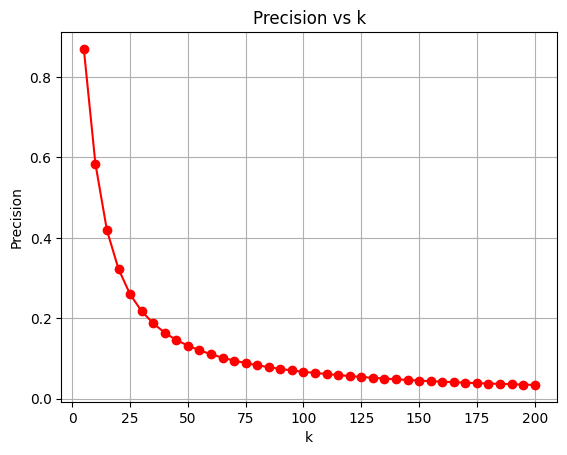

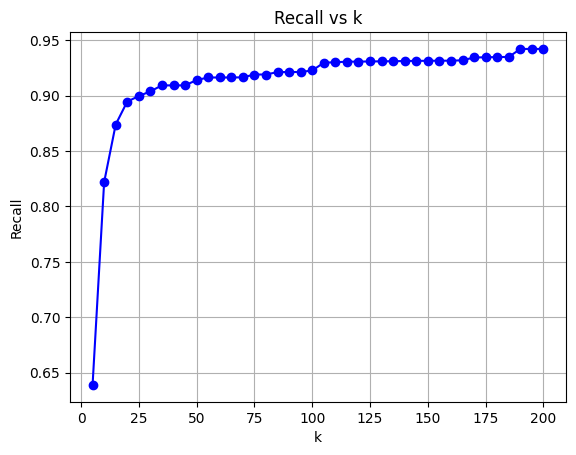

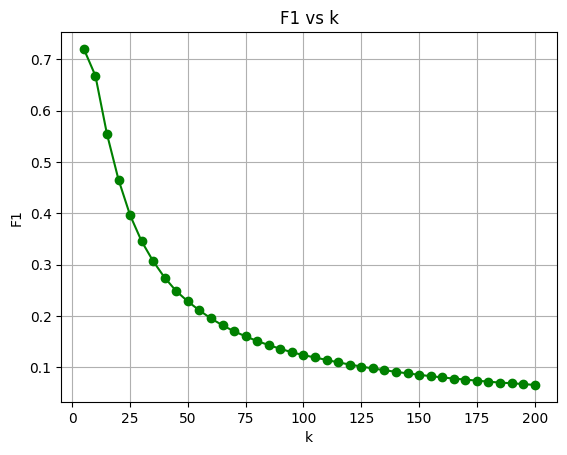

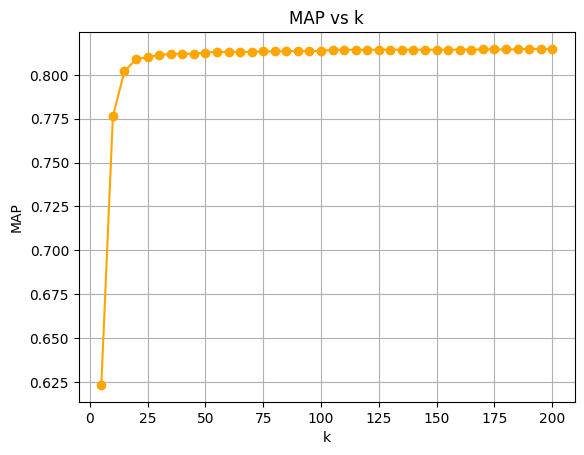

In [ ]:
import matplotlib.pyplot as plt

metrics = ["Precision", "Recall", "F1", "MAP"]
colors = ["red", "blue", "green", "orange"]

for metric, color in zip(metrics, colors):
    plt.figure()
    plt.plot(df_metrics["k"], df_metrics[metric], marker="o", color=color)
    plt.title(f"{metric} vs k")
    plt.xlabel("k")
    plt.ylabel(metric)
    plt.grid(True)
    plt.show()


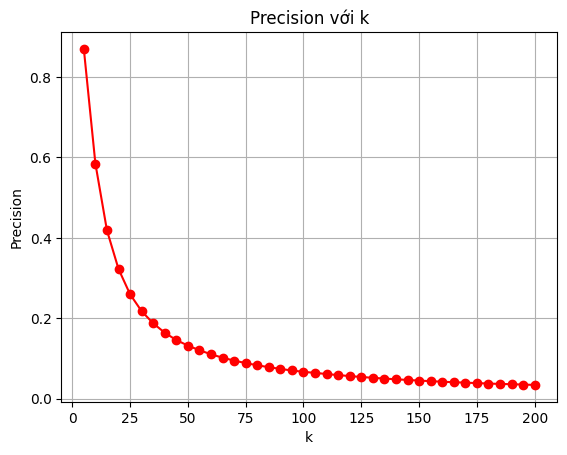

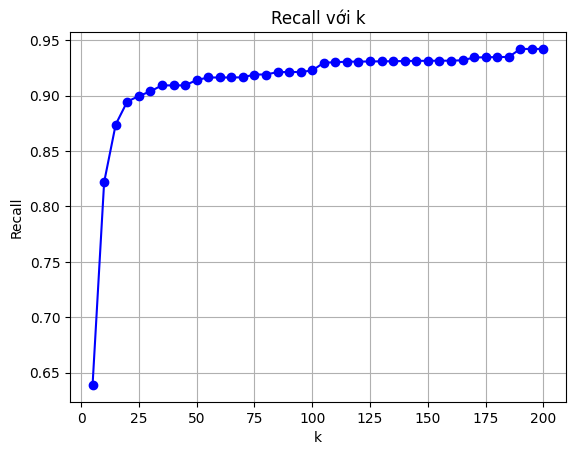

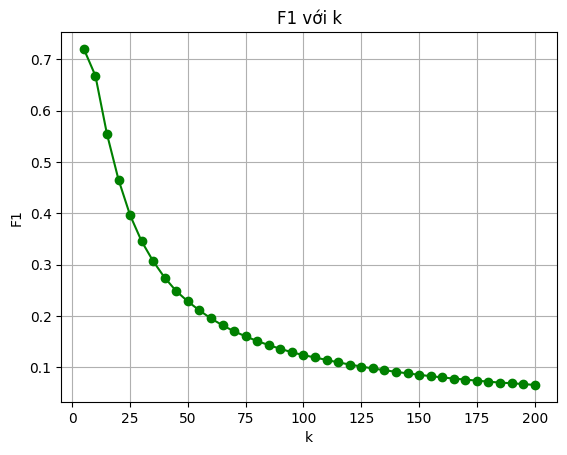

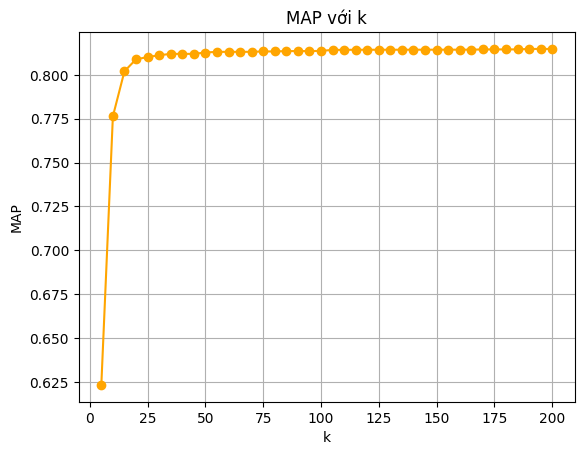

In [ ]:
import matplotlib.pyplot as plt

metrics = ["Precision", "Recall", "F1", "MAP"]
colors = ["red", "blue", "green", "orange"]

for metric, color in zip(metrics, colors):
    plt.figure()
    plt.plot(df_metrics["k"], df_metrics[metric], marker="o", color=color)
    plt.title(f"{metric} với k")
    plt.xlabel("k")
    plt.ylabel(metric)
    plt.grid(True)
    plt.show()


# END

In [ ]:
'''
train,  val
((5521, 3), (1183, 3), (1184, 3))

47: 0.7859240174293518
51: 0.946254312992096
249: 0.9021667242050171
532: 0.8886623978614807
562: 0.7486081719398499

'''

'\ntrain,  val\n((5521, 3), (1183, 3), (1184, 3))\n\n\n\n'